# What do we really want in classification?

To *minimize* the risk of misclassifying an observation $\mathbf{z} \in \mathbb{R}^M$:

Choose the class with the minimum expected risk: $\omega^* = \arg \min_{\omega \in \Omega} R(\omega | \mathbf{z})$

Where the risk is defined: $R(\omega | \mathbf{z}) = \sum_{\hat\omega \in \Omega} C(\omega,\hat\omega)P(\hat\omega|\mathbf{z})$

We just have to define the cost $C(\omega,\hat\omega)$ and estimate the posterior distributions $P(\hat\omega|\mathbf{z})$.


# What do we really want in classification?

If we define $C(\omega,\hat\omega)$ as the zero-one loss (all misclassifications carry a cost of 1, and all correct classification carry a cost of 0), we get the Bayes' Classifier:

\begin{align}
\omega_{\textrm{B}} & = \arg \max_{\omega \in \Omega} P(\omega | \mathbf{z}) \\
& = \arg \max_{\omega \in \Omega} P(\mathbf{z}|\omega)P(\omega)
\end{align}

where 
- $P(\mathbf{z}|\omega)$ is the *likelihood* of $\mathbf{z}$ being generated by class $\omega$
- $P(\omega)$ is the *prior* of the class $\omega$ before any observation is made

## This is Maximum a Posteriori (MAP) classification


# Bayes classification with different model assumptions

Linear discriminant analysis (LDA) and Quadratic discriminant analysis (QDA)
defines the loss to be 0-1, and assumes
- observations are distributed Gaussian 
- observations of each class have a unique mean

But:
- LDA assumes a single covariance matrix for all observations of the classes.
- QDA assumes a different covariance matrix for the observations of each class.

Let's get some intuition for these classifiers.

# Synthetic dataset

Define two 2-D Gaussian distributions with the same covariance 
$$C = \begin{pmatrix} 1 & 0.2 \\ 0.2 & 1 \end{pmatrix}$$ 
but different means $\mu_1 = (1,1)$ and $\mu_2 = (-1, -1)$. 

We sample 1000 points from each of these distributions and make a scatter plot.

<Figure size 1000x1000 with 0 Axes>

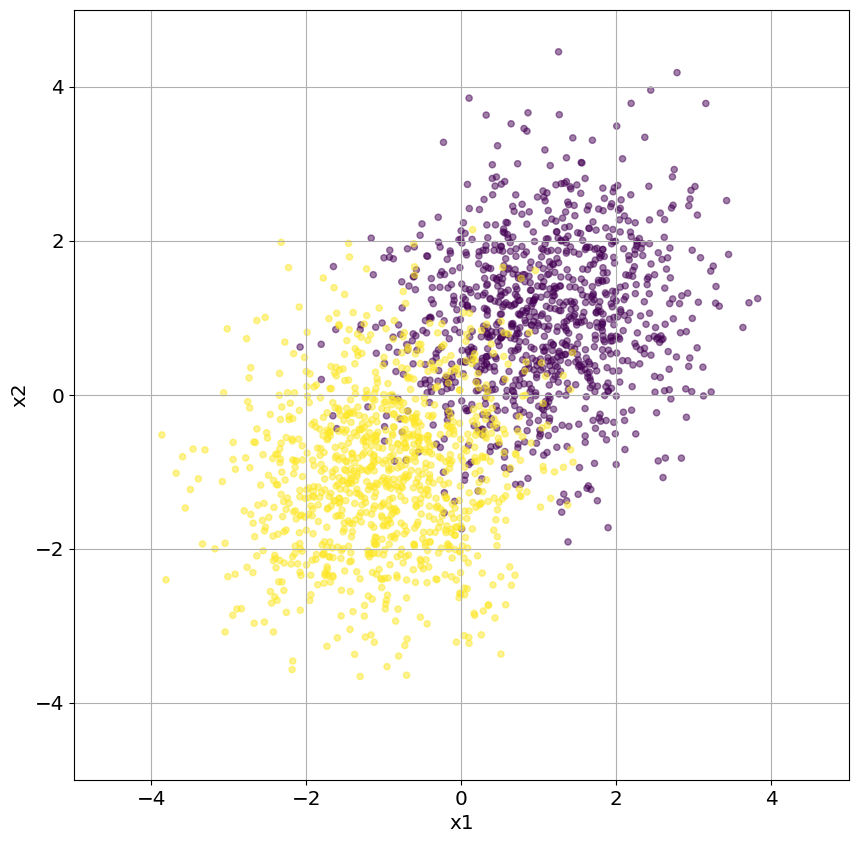

In [11]:
import numpy as np
import pandas as pd
numvecs=1000
param_cov = [[1, 0.2], [0.2, 1]]
param_mean1 = [1, 1]; param_mean2 = [-1, -1]

df = pd.DataFrame(np.random.multivariate_normal(param_mean1,param_cov,numvecs),
         columns=['x1', 'x2']); df['y'] = 0
df2 = pd.DataFrame(np.random.multivariate_normal(param_mean2,param_cov,
         numvecs),columns=['x1', 'x2']); df2['y'] = 1

df = pd.concat([df,df2],ignore_index=True)

import matplotlib.pyplot as plt
params = {'legend.fontsize': 'x-large','figure.figsize': (10, 10),
         'axes.labelsize': 'x-large','axes.titlesize':'x-large',
         'xtick.labelsize':'x-large','ytick.labelsize':'x-large'}
plt.rcParams.update(params)

fig = plt.figure()
df.plot.scatter('x1','x2',c='y',colorbar=False,cmap='viridis',alpha=0.5)
plt.xlim((-5, 5)); plt.ylim((-5, 5))
plt.grid(); plt.show()

# Linear discriminant analysis

We create an LDA classifier from this dataset and plot its decision regions.

*Remember*: the assumption is that the covariance of the observations of each class is the same.

Note: default for *LinearDiscriminantAnalysis* is all classes are equally likely

/Users/bobs/anaconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearDiscriminantAnalysis was fitted with feature names
  warnings.warn(


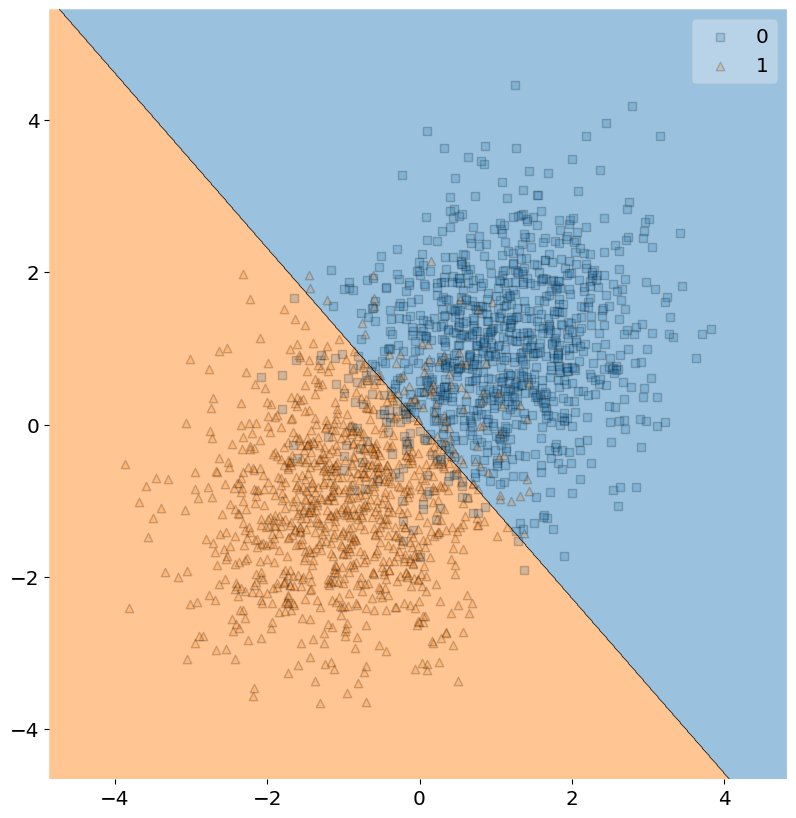

In [12]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
clfLDA = LinearDiscriminantAnalysis()
clfLDA.fit(df[['x1','x2']],df['y'])
from mlxtend.plotting import plot_decision_regions
plot_decision_regions(df[['x1','x2']].to_numpy(), df['y'].to_numpy(), 
                    clf=clfLDA, scatter_kwargs={'alpha':0.2}).set_aspect('equal', adjustable='box')

# Non-uniform priors

What happens to the LDA decision boundary when the prior probabilities of the classes are different? 

/Users/bobs/anaconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearDiscriminantAnalysis was fitted with feature names
  warnings.warn(


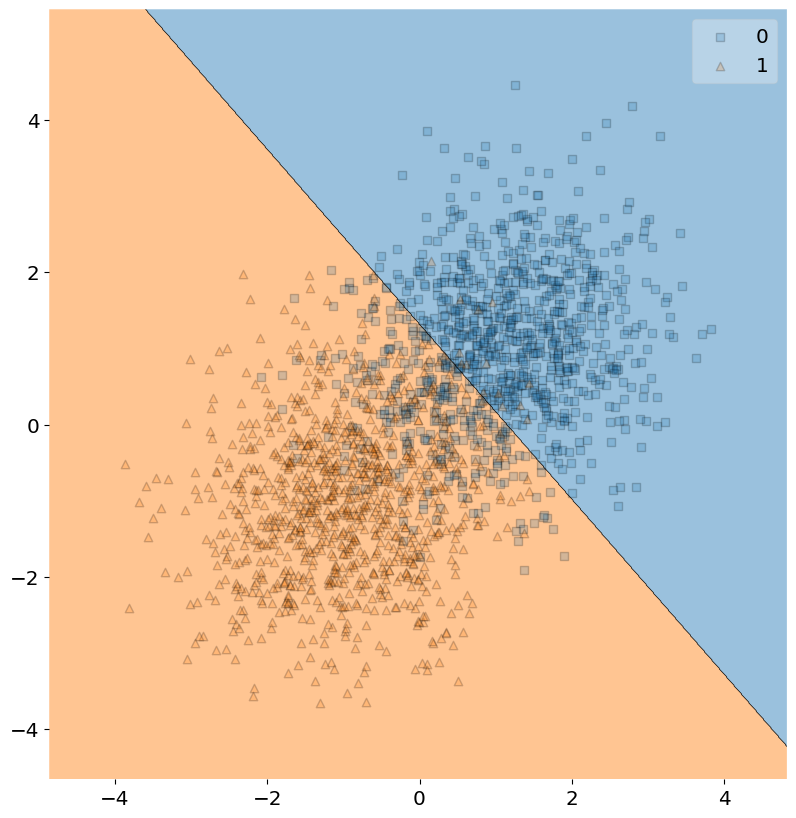

In [13]:
clfLDA = LinearDiscriminantAnalysis(priors=[0.1, 0.9])
clfLDA.fit(df[['x1','x2']],df['y'])
from mlxtend.plotting import plot_decision_regions
plot_decision_regions(df[['x1','x2']].to_numpy(), df['y'].to_numpy(), 
                    clf=clfLDA, scatter_kwargs={'alpha':0.2}).set_aspect('equal', adjustable='box')

# Quadratic discriminant analysis

We create a QDA classifier from this dataset and plot its decision regions.

*Remember*: the assumption is that the covariance of the observations of each class can be different.

Note: default for *QuadraticDiscriminantAnalysis* is all classes are equally likely

/Users/bobs/anaconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but QuadraticDiscriminantAnalysis was fitted with feature names
  warnings.warn(


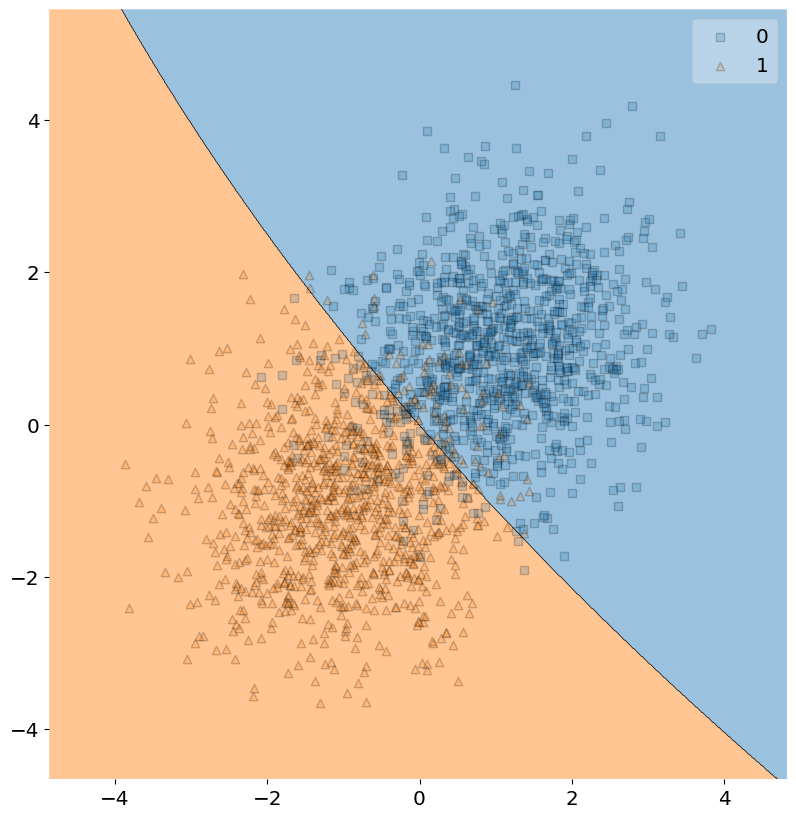

In [14]:
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
clfQDA = QuadraticDiscriminantAnalysis()
clfQDA.fit(df[['x1','x2']],df['y'])
from mlxtend.plotting import plot_decision_regions
plot_decision_regions(df[['x1','x2']].to_numpy(), df['y'].to_numpy(), 
                    clf=clfQDA, scatter_kwargs={'alpha':0.2}).set_aspect('equal', adjustable='box')

# Non-uniform priors

What happens to the QDA decision boundary when the prior probabilities of the classes are different? 

/Users/bobs/anaconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but QuadraticDiscriminantAnalysis was fitted with feature names
  warnings.warn(


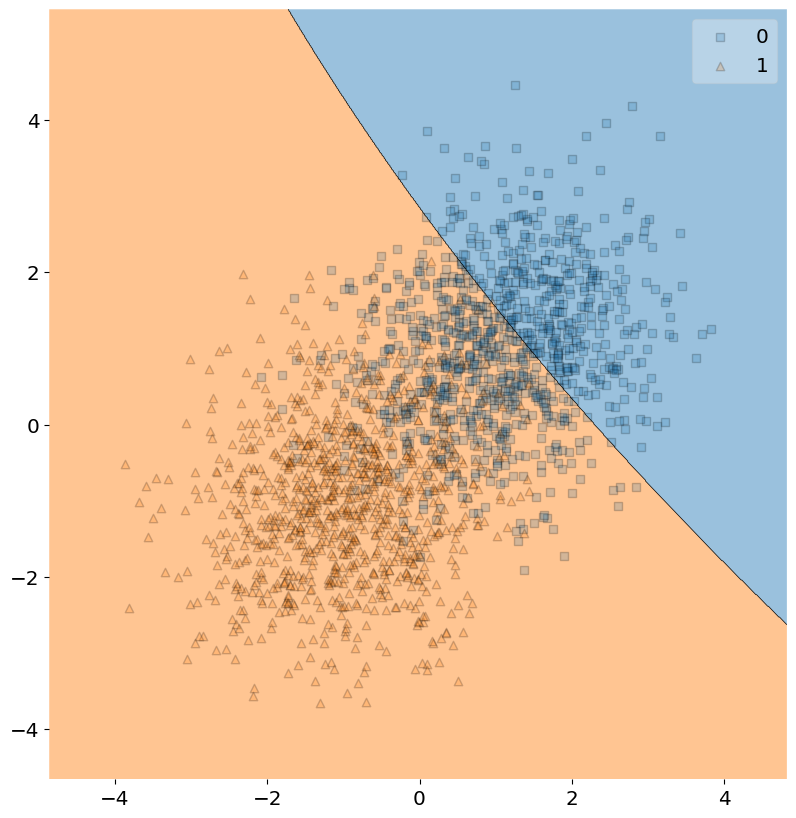

In [15]:
clfQDA = QuadraticDiscriminantAnalysis(priors=[0.01, 0.99])
clfQDA.fit(df[['x1','x2']],df['y'])
from mlxtend.plotting import plot_decision_regions
plot_decision_regions(df[['x1','x2']].to_numpy(), df['y'].to_numpy(), 
                    clf=clfQDA, scatter_kwargs={'alpha':0.2}).set_aspect('equal', adjustable='box')

# Another Synthetic dataset

Define two 2-D Gaussian distributions with the covariances
$$C_1 = \begin{pmatrix} 1 & 0.2 \\ 0.2 & 1 \end{pmatrix}$$ 
$$C_2 = \begin{pmatrix} 1 & -0.2 \\ -0.2 & 1 \end{pmatrix}$$ 
and means $\mu_1 = (1,1)$ and $\mu_2 = (-1, -1)$. 

We sample 1000 points from each of these distributions and make a scatter plot.

<Figure size 1000x1000 with 0 Axes>

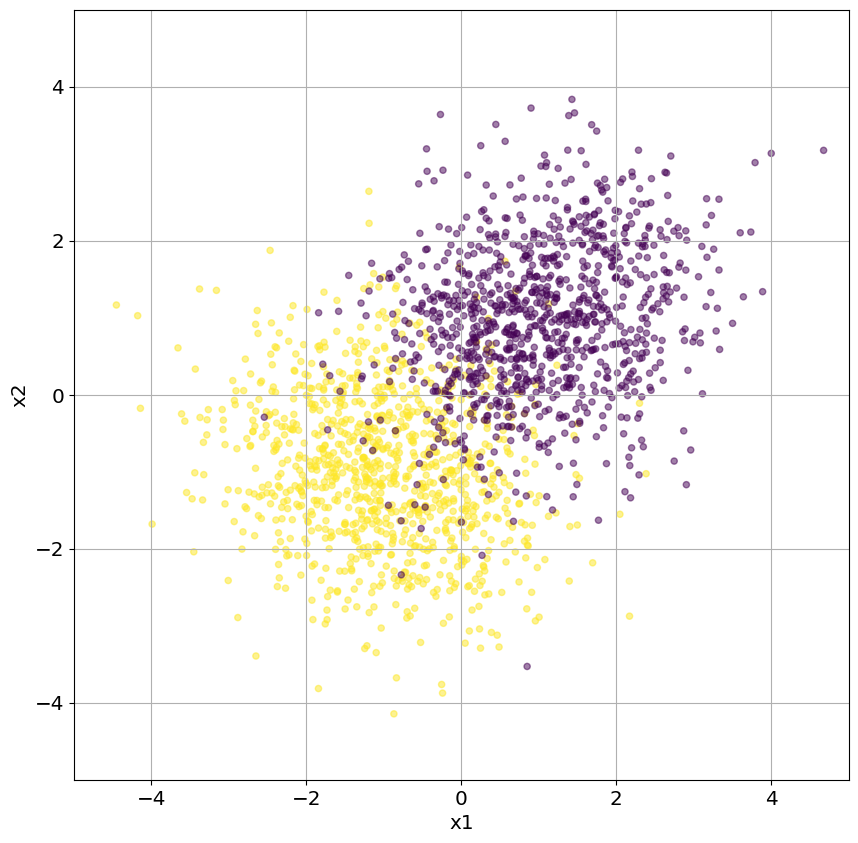

In [17]:
param_cov1 = [[1, 0.2], [0.2, 1]]; param_cov2 = [[1, -0.2], [-0.2, 1]]
param_mean1 = [1, 1]; param_mean2 = [-1, -1]

df = pd.DataFrame(np.random.multivariate_normal(param_mean1,param_cov1,numvecs),
         columns=['x1', 'x2']); df['y'] = 0
df2 = pd.DataFrame(np.random.multivariate_normal(param_mean2,param_cov2,numvecs),
         columns=['x1', 'x2']); df2['y'] = 1

df = pd.concat([df2,df],ignore_index=True)

fig = plt.figure()
df.plot.scatter('x1','x2',c='y',colorbar=False,cmap='viridis',alpha=0.5)
plt.xlim((-5, 5)); plt.ylim((-5, 5))
plt.grid(); plt.show()

# Linear discriminant analysis

We create an LDA classifier from this dataset and plot its decision regions.

/Users/bobs/anaconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearDiscriminantAnalysis was fitted with feature names
  warnings.warn(


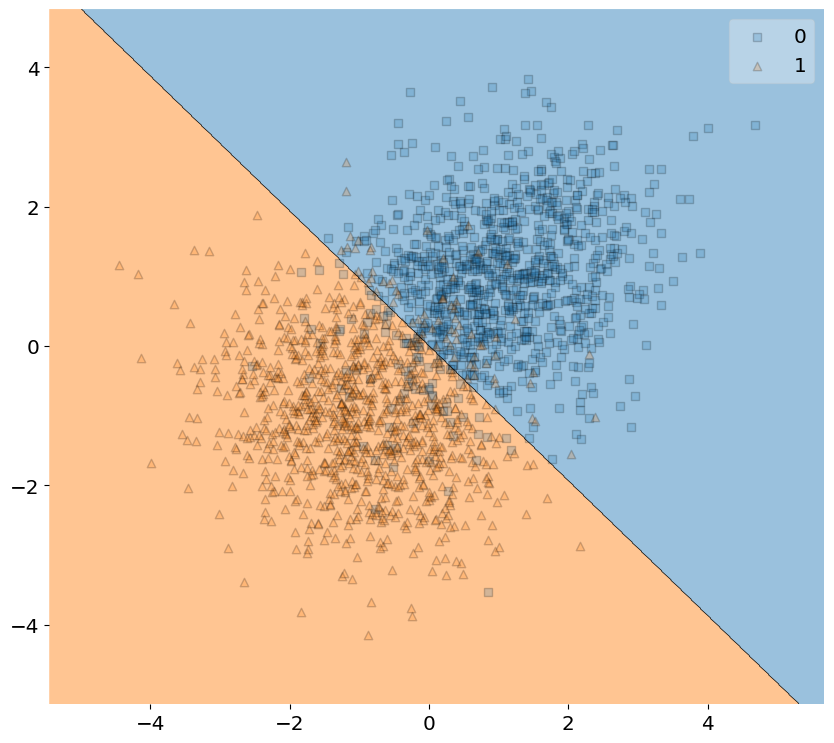

In [18]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
clfLDA = LinearDiscriminantAnalysis(priors=[0.5, 0.5])
clfLDA.fit(df[['x1','x2']],df['y'])
from mlxtend.plotting import plot_decision_regions
plot_decision_regions(df[['x1','x2']].to_numpy(), df['y'].to_numpy(), 
                    clf=clfLDA, scatter_kwargs={'alpha':0.2}).set_aspect('equal', adjustable='box')

# Quadratic discriminant analysis

We create a QDA classifier from this dataset and plot its decision regions.

/Users/bobs/anaconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but QuadraticDiscriminantAnalysis was fitted with feature names
  warnings.warn(


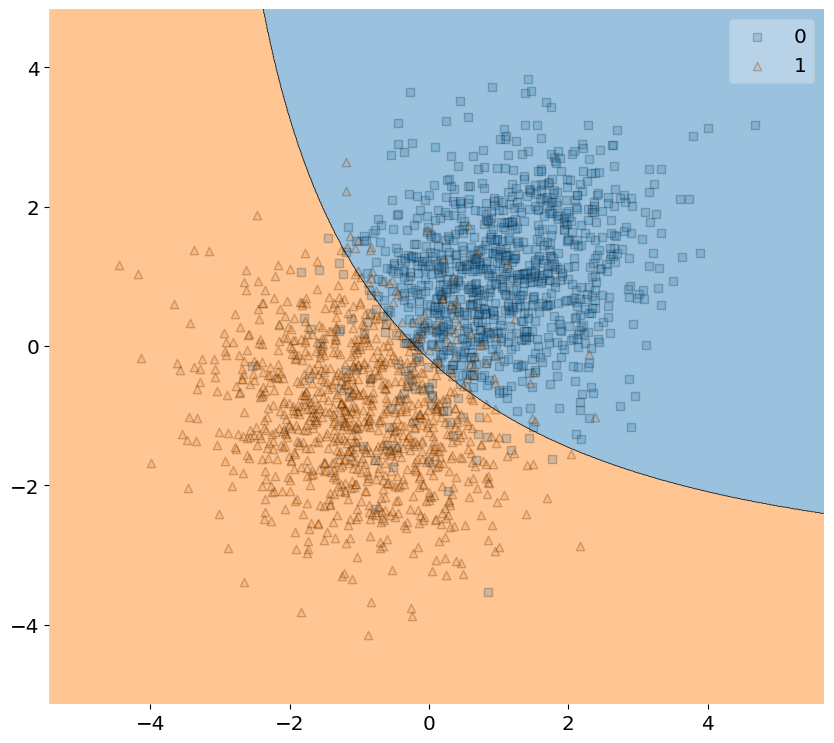

In [19]:
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
clfQDA = QuadraticDiscriminantAnalysis(priors=[0.5, 0.5])
clfQDA.fit(df[['x1','x2']],df['y'])
from mlxtend.plotting import plot_decision_regions
plot_decision_regions(df[['x1','x2']].to_numpy(), df['y'].to_numpy(), 
                    clf=clfQDA, scatter_kwargs={'alpha':0.2}).set_aspect('equal', adjustable='box')

# Another Synthetic dataset

Define two 2-D Gaussian distributions with the covariances
$$C_1 = \begin{pmatrix} 2 & 0.2 \\ 0.2 & 1 \end{pmatrix}$$ 
$$C_2 = \begin{pmatrix} 1 & -0.2 \\ -0.2 & 1 \end{pmatrix}$$ 
and means $\mu_1 = \mu_2 = (1,1)$. 

We sample 1000 points from each of these distributions and make a scatter plot.

<Figure size 1000x1000 with 0 Axes>

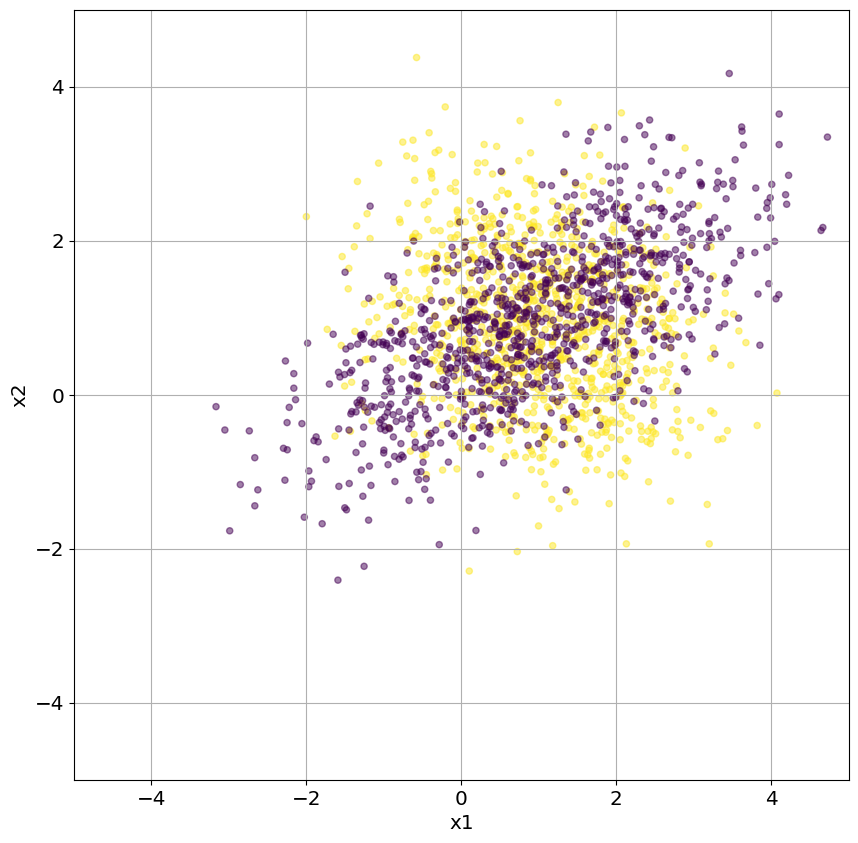

In [21]:
param_cov1 = [[2, 0.9], [0.9, 1]]; param_cov2 = [[1, -0.2], [-0.2, 1]]
param_mean = [1, 1]

df = pd.DataFrame(np.random.multivariate_normal(param_mean,param_cov1,numvecs),
         columns=['x1', 'x2']); df['y'] = 0
df2 = pd.DataFrame(np.random.multivariate_normal(param_mean,param_cov2,numvecs),
         columns=['x1', 'x2']); df2['y'] = 1

df = pd.concat([df2,df],ignore_index=True)

fig = plt.figure()
df.plot.scatter('x1','x2',c='y',colorbar=False,cmap='viridis',alpha=0.5)
plt.xlim((-5, 5)); plt.ylim((-5, 5))
plt.grid(); plt.show()

# Linear discriminant analysis

We create an LDA classifier from this dataset and plot its decision regions.

/Users/bobs/anaconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearDiscriminantAnalysis was fitted with feature names
  warnings.warn(


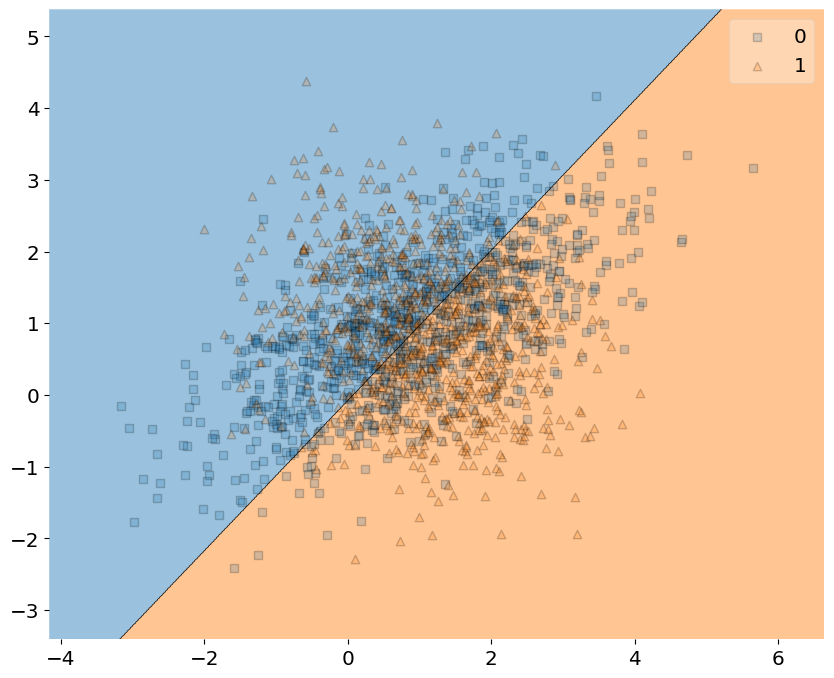

In [22]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
clfLDA = LinearDiscriminantAnalysis(priors=[0.5, 0.5])
clfLDA.fit(df[['x1','x2']],df['y'])
from mlxtend.plotting import plot_decision_regions
plot_decision_regions(df[['x1','x2']].to_numpy(), df['y'].to_numpy(), 
                    clf=clfLDA, scatter_kwargs={'alpha':0.2}).set_aspect('equal', adjustable='box')

# Quadratic discriminant analysis

We create a QDA classifier from this dataset and plot its decision regions.

/Users/bobs/anaconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but QuadraticDiscriminantAnalysis was fitted with feature names
  warnings.warn(


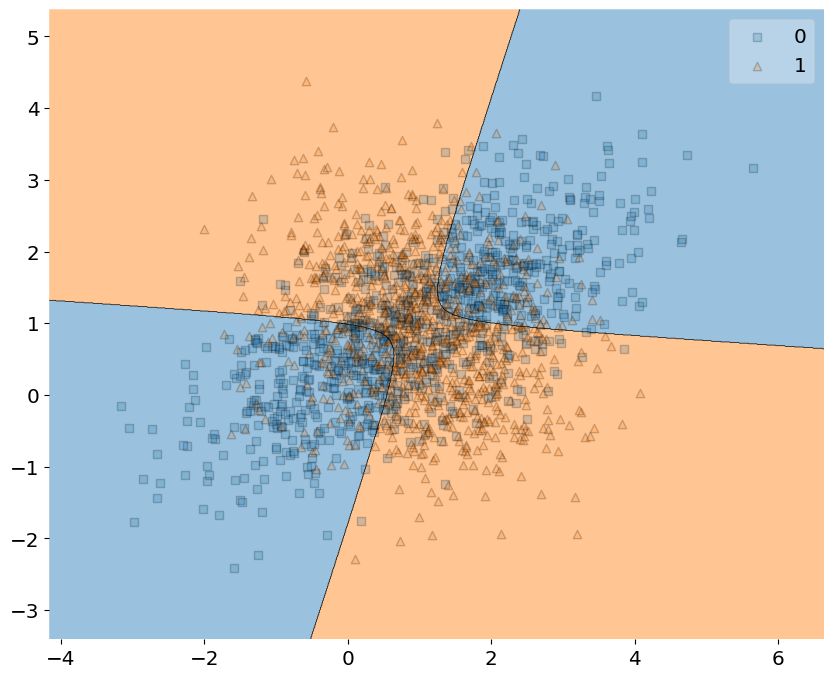

In [23]:
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
clfQDA = QuadraticDiscriminantAnalysis(priors=[0.5, 0.5])
clfQDA.fit(df[['x1','x2']],df['y'])
from mlxtend.plotting import plot_decision_regions
plot_decision_regions(df[['x1','x2']].to_numpy(), df['y'].to_numpy(), 
                    clf=clfQDA, scatter_kwargs={'alpha':0.2}).set_aspect('equal', adjustable='box')

# Another Synthetic dataset

Define two 2-D Gaussian distributions with the covariances
$$C_1 = \begin{pmatrix} 2 & 0.2 \\ 0.2 & 2\end{pmatrix}$$ 
$$C_2 = \begin{pmatrix} 1 & 0.2 \\ 0.2 & 1 \end{pmatrix}$$ 
and means $\mu_1 = \mu_2 = (1,1)$. 

We sample 1000 points from each of these distributions and make a scatter plot.

<Figure size 1000x1000 with 0 Axes>

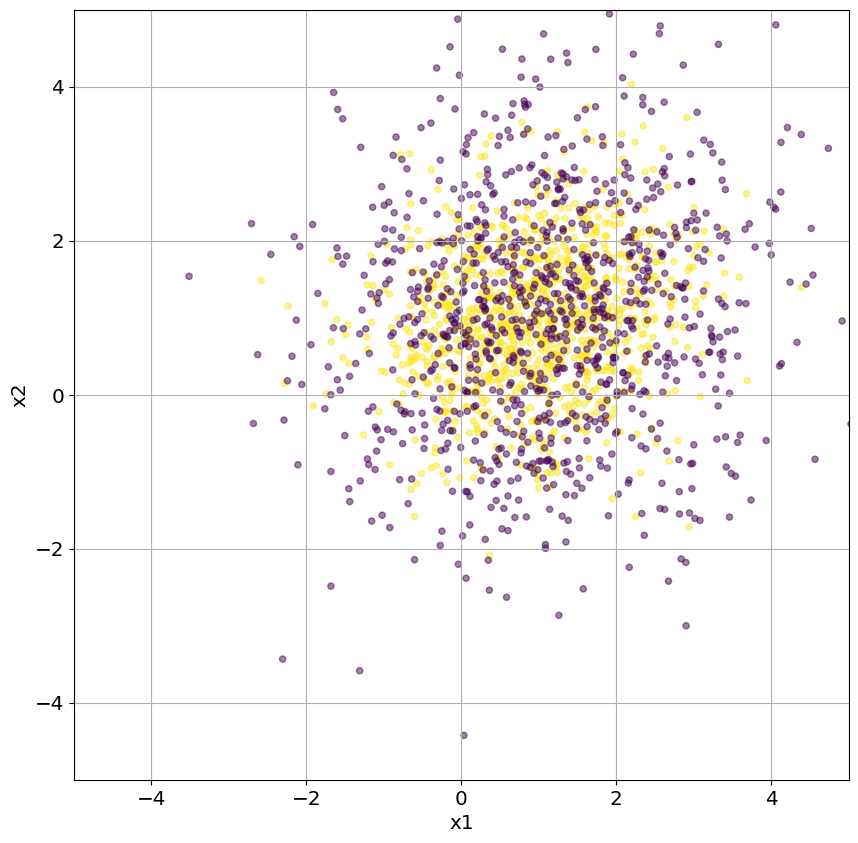

In [25]:
param_cov1 = [[2, 0.2], [0.2, 2]]; param_cov2 = [[1, 0.2], [0.2, 1]]
param_mean = [1, 1]

df = pd.DataFrame(np.random.multivariate_normal(param_mean,param_cov1,numvecs),
         columns=['x1', 'x2']); df['y'] = 0
df2 = pd.DataFrame(np.random.multivariate_normal(param_mean,param_cov2,numvecs),
         columns=['x1', 'x2']); df2['y'] = 1

df = pd.concat([df2,df],ignore_index=True)

fig = plt.figure()
df.plot.scatter('x1','x2',c='y',colorbar=False,cmap='viridis',alpha=0.5)
plt.xlim((-5, 5)); plt.ylim((-5, 5))
plt.grid(); plt.show()

# Linear discriminant analysis

We create an LDA classifier from this dataset and plot its decision regions.

/Users/bobs/anaconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearDiscriminantAnalysis was fitted with feature names
  warnings.warn(


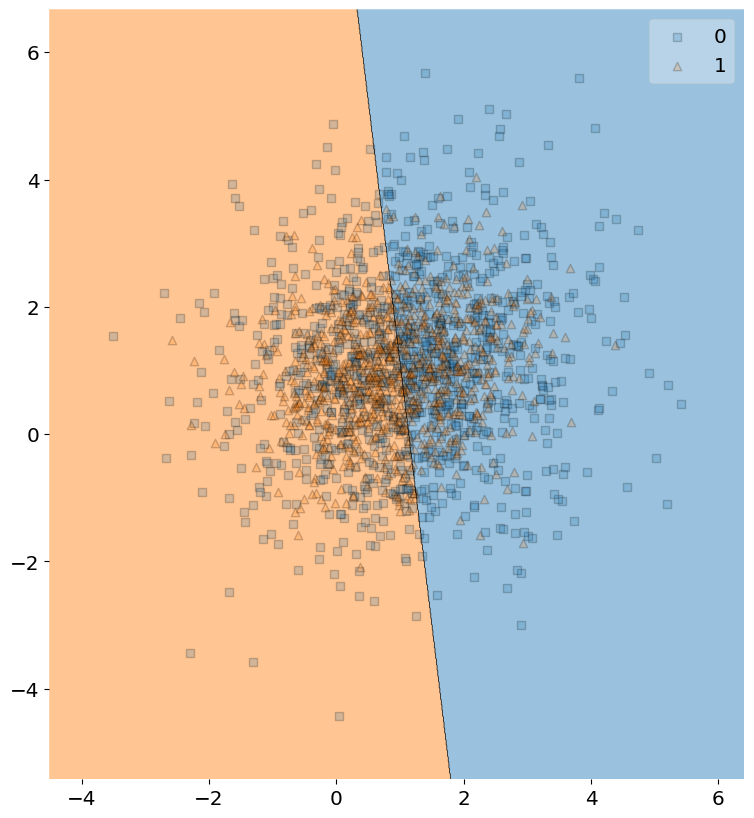

In [26]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
clfLDA = LinearDiscriminantAnalysis(priors=[0.5, 0.5])
clfLDA.fit(df[['x1','x2']],df['y'])
from mlxtend.plotting import plot_decision_regions
plot_decision_regions(df[['x1','x2']].to_numpy(), df['y'].to_numpy(), 
                    clf=clfLDA, scatter_kwargs={'alpha':0.2}).set_aspect('equal', adjustable='box')

# Quadratic discriminant analysis

We create a QDA classifier from this dataset and plot its decision regions.

/Users/bobs/anaconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but QuadraticDiscriminantAnalysis was fitted with feature names
  warnings.warn(


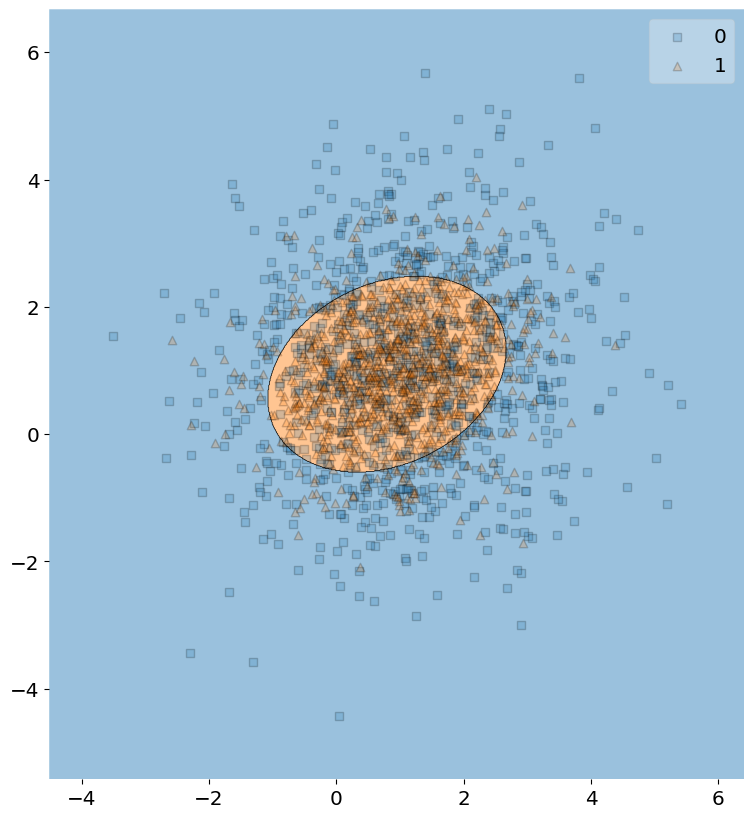

In [27]:
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
clfQDA = QuadraticDiscriminantAnalysis(priors=[0.5, 0.5])
clfQDA.fit(df[['x1','x2']],df['y'])
from mlxtend.plotting import plot_decision_regions
plot_decision_regions(df[['x1','x2']].to_numpy(), df['y'].to_numpy(), 
                    clf=clfQDA, scatter_kwargs={'alpha':0.2}).set_aspect('equal', adjustable='box')

# Bayes Classification with assumptions

Linear discriminant analysis (LDA) and Quadratic discriminant analysis (QDA)
defines the loss to be 0-1, and assumes:
- observations are distributed Gaussian 
- observations of each class have a unique mean

No hyperparameters to tune. 

Closed form solutions.

# Linear discriminant analysis (LDA)

LDA assumes there is a single covariance matrix for all class observations. 
- The decision boundary is always a straight line.
- This is a very simple decision function.
- Only have to estimate class means and a single covariance matrix

# Quadratic discriminant analysis (QDA)

QDA assumes observations of each class distributed with possibly unique covariances
- The decision boundary is a quadratic function of the independent variables
- More parameters to estimate and so needs more data than LDA
- Decision function is more complex, and so can be more expressive.

# Bayes Classification with assumptions

What is the result of the following strategy?
- Define loss to be 0-1
- Assume observations are distributed Gaussian 
- Assume observations of each class have a unique mean
- Assume all covariance matrices are diagonal

This is _Naive Bayes_.

/Users/bobs/anaconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but GaussianNB was fitted with feature names
  warnings.warn(


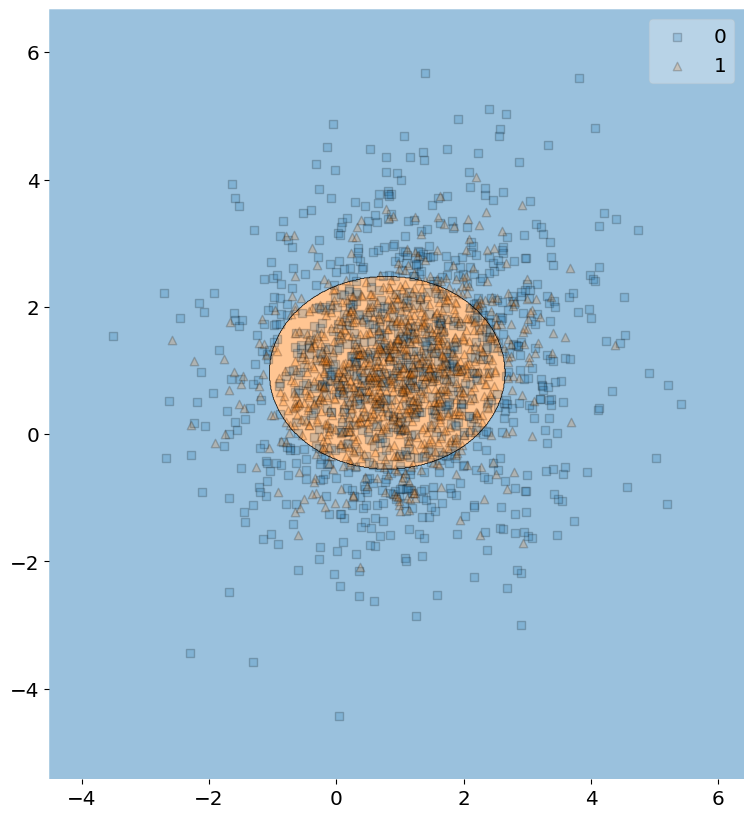

In [28]:
from sklearn.naive_bayes import GaussianNB
clfGNB = GaussianNB(priors=[0.5,0.5])
clfGNB.fit(df[['x1','x2']],df['y'])
from mlxtend.plotting import plot_decision_regions
plot_decision_regions(df[['x1','x2']].to_numpy(), df['y'].to_numpy(), 
                    clf=clfGNB, scatter_kwargs={'alpha':0.2}).set_aspect('equal', adjustable='box')

## Let's apply these to data we have seen before

In [37]:
from sklearn.datasets import load_breast_cancer
cancer_dataset = load_breast_cancer()
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    cancer_dataset['data'], cancer_dataset['target'], random_state=0)

clfLDA = LinearDiscriminantAnalysis()
clfLDA.fit(X_train,y_train)
clfQDA = QuadraticDiscriminantAnalysis(reg_param=0.2)
clfQDA.fit(X_train,y_train)
clfGNB = GaussianNB()
clfGNB.fit(X_train,y_train)

from sklearn.metrics import classification_report
print('LDA:')
print(classification_report(y_test, clfLDA.predict(X_test),target_names=cancer_dataset.target_names))
print('QDA:')
print(classification_report(y_test, clfQDA.predict(X_test),target_names=cancer_dataset.target_names))
print('NB:')
print(classification_report(y_test, clfGNB.predict(X_test),target_names=cancer_dataset.target_names))


LDA:
              precision    recall  f1-score   support

   malignant       1.00      0.92      0.96        53
      benign       0.96      1.00      0.98        90

    accuracy                           0.97       143
   macro avg       0.98      0.96      0.97       143
weighted avg       0.97      0.97      0.97       143

QDA:
              precision    recall  f1-score   support

   malignant       0.93      0.98      0.95        53
      benign       0.99      0.96      0.97        90

    accuracy                           0.97       143
   macro avg       0.96      0.97      0.96       143
weighted avg       0.97      0.97      0.97       143

NB:
              precision    recall  f1-score   support

   malignant       0.92      0.91      0.91        53
      benign       0.95      0.96      0.95        90

    accuracy                           0.94       143
   macro avg       0.93      0.93      0.93       143
weighted avg       0.94      0.94      0.94       143



## Let's add priors now to avoid false negatives

In [39]:
priors=[0.9,0.1]

clfLDA = LinearDiscriminantAnalysis(priors=priors)
clfLDA.fit(X_train,y_train)
clfQDA = QuadraticDiscriminantAnalysis(priors=priors,reg_param=0.2)
clfQDA.fit(X_train,y_train)
clfGNB = GaussianNB(priors=priors)
clfGNB.fit(X_train,y_train)

from sklearn.metrics import classification_report
print('LDA:')
print(classification_report(y_test, clfLDA.predict(X_test),target_names=cancer_dataset.target_names))
print('QDA:')
print(classification_report(y_test, clfQDA.predict(X_test),target_names=cancer_dataset.target_names))
print('NB:')
print(classification_report(y_test, clfGNB.predict(X_test),target_names=cancer_dataset.target_names))


LDA:
              precision    recall  f1-score   support

   malignant       0.91      0.96      0.94        53
      benign       0.98      0.94      0.96        90

    accuracy                           0.95       143
   macro avg       0.94      0.95      0.95       143
weighted avg       0.95      0.95      0.95       143

QDA:
              precision    recall  f1-score   support

   malignant       0.90      1.00      0.95        53
      benign       1.00      0.93      0.97        90

    accuracy                           0.96       143
   macro avg       0.95      0.97      0.96       143
weighted avg       0.96      0.96      0.96       143

NB:
              precision    recall  f1-score   support

   malignant       0.91      0.92      0.92        53
      benign       0.96      0.94      0.95        90

    accuracy                           0.94       143
   macro avg       0.93      0.93      0.93       143
weighted avg       0.94      0.94      0.94       143

